## Imports

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.model_selection import (train_test_split, cross_validate, GridSearchCV,
                                     RandomizedSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.inspection import permutation_importance
import datetime

from lib.sb_utils import save_file


## Load Data

In [2]:
# Load cleaned EDA data and look at features
college_data = pd.read_csv('../data/college_data_EDA.csv')
college_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  349 non-null    object 
 1   Private               349 non-null    int64  
 2   Top10perc             349 non-null    int64  
 3   Top25perc             349 non-null    int64  
 4   Room.Board            349 non-null    int64  
 5   PhD                   349 non-null    int64  
 6   S.F.Ratio             349 non-null    float64
 7   perc.alumni           349 non-null    int64  
 8   Expend                349 non-null    int64  
 9   Grad.Rate             349 non-null    int64  
 10  state                 349 non-null    object 
 11  out_of_state_tuition  349 non-null    float64
dtypes: float64(2), int64(8), object(2)
memory usage: 32.8+ KB


In [3]:
# Look at college of interest
purdue = college_data[college_data.name.str.match('^Purdue')]
college_data = college_data[~college_data.name.str.match('^Purdue')]
purdue.head()

,name,Private,Top10perc,Top25perc,Room.Board,PhD,S.F.Ratio,perc.alumni,Expend,Grad.Rate,state,out_of_state_tuition
198,Purdue University at West Lafayette,0,29,60,3990,86,18.2,15,8604,67,Indiana,28794.0


## Train/Test Split

In [4]:
# Split data into train and test splits
X_train, X_test, y_train, y_test = train_test_split(college_data.drop(columns='out_of_state_tuition'), 
                                                    college_data.out_of_state_tuition,
                                                    test_size=0.3,
                                                    random_state=67)

In [5]:
# Save name column, drop it from features. State is kept — dropped after state_mean encoding below.
names_train = X_train['name']
names_test = X_test['name']
X_train = X_train.drop(columns='name')
X_test = X_test.drop(columns='name')
X_train.shape, X_test.shape

((243, 10), (105, 10))

### Target-encode `state` from training data only

`state_mean` was previously computed across the full dataset in EDA, which leaked test-set target
info into training. Here we compute per-state mean tuition from the training set only, then apply
the mapping to train, test, and Purdue. States not seen in training fall back to the overall
training mean.

In [6]:
# Compute state -> mean tuition mapping from TRAINING data only
state_mean_map = y_train.groupby(X_train['state']).mean()
overall_train_mean = y_train.mean()

# Apply the mapping; unseen states in test/Purdue fall back to the overall training mean
X_train['state_mean'] = X_train['state'].map(state_mean_map).fillna(overall_train_mean)
X_test['state_mean']  = X_test['state'].map(state_mean_map).fillna(overall_train_mean)
purdue = purdue.copy()
purdue['state_mean']  = purdue['state'].map(state_mean_map).fillna(overall_train_mean)

# Drop raw `state` from modeling inputs
X_train = X_train.drop(columns='state')
X_test  = X_test.drop(columns='state')
purdue  = purdue.drop(columns='state')
X_train.columns.tolist()

['Private',
 'Top10perc',
 'Top25perc',
 'Room.Board',
 'PhD',
 'S.F.Ratio',
 'perc.alumni',
 'Expend',
 'Grad.Rate',
 'state_mean']

In [7]:
# Ensure preprocessed datatypes
X_train.dtypes

Private          int64
Top10perc        int64
Top25perc        int64
Room.Board       int64
PhD              int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
state_mean     float64
dtype: object

In [8]:
# Ensure preprocessed null values
college_data.isna().sum()

name                    0
Private                 0
Top10perc               0
Top25perc               0
Room.Board              0
PhD                     0
S.F.Ratio               0
perc.alumni             0
Expend                  0
Grad.Rate               0
state                   0
out_of_state_tuition    0
dtype: int64

## Hyperparameter GridSearch Linear Regression

In [9]:
# Linear regression pipeline
lr_pipe = make_pipeline(
    StandardScaler(),
    SelectKBest(f_regression),
    LinearRegression()
)

In [10]:
# Different hyperparameters to test
k = np.arange(1, len(X_train.columns)+1)
param_grid = {'selectkbest__k': k}

In [11]:
# Grid search for hyperparameters
lr_grid_cv = GridSearchCV(lr_pipe, param_grid=param_grid, cv=5, n_jobs=-1)

In [12]:
# Fit model to training data
lr_grid_cv.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'selectkbest__k': array([ 1, 2..., 8, 9, 10])}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [13]:
# Load scores and check optimal hyperparameters
score_mean = lr_grid_cv.cv_results_['mean_test_score']
score_std = lr_grid_cv.cv_results_['std_test_score']
lr_grid_cv.best_params_

{'selectkbest__k': np.int64(10)}

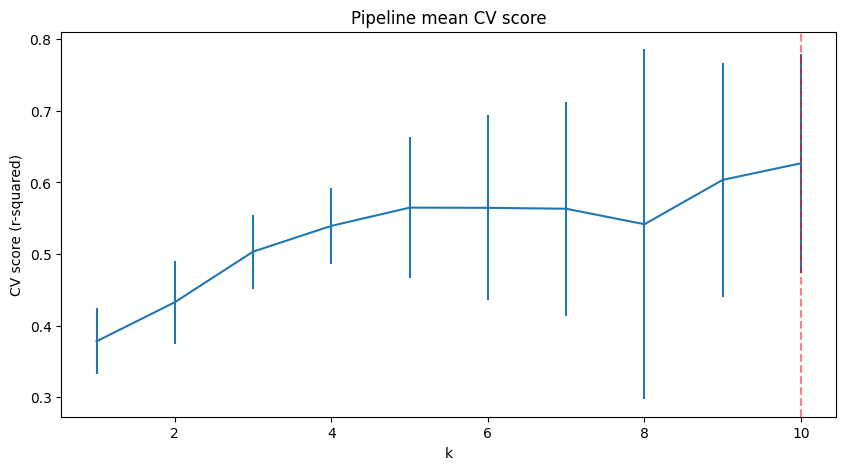

In [14]:
# Display visualization of performance at different number of features (k)
best_k = lr_grid_cv.best_params_['selectkbest__k']
plt.subplots(figsize=(10, 5))
plt.errorbar(k, score_mean, yerr=score_std)
plt.axvline(x=best_k, c='r', ls='--', alpha=.5)
plt.xlabel('k')
plt.ylabel('CV score (r-squared)')
plt.title('Pipeline mean CV score');

In [15]:
# Find best hyperparameters of a Linear Regression model
selected = lr_grid_cv.best_estimator_.named_steps.selectkbest.get_support()
coefs = lr_grid_cv.best_estimator_.named_steps.linearregression.coef_
features = X_train.columns[selected]
pd.Series(coefs, index=features).sort_values(ascending=True)

Top10perc      -285.357184
S.F.Ratio       142.155243
perc.alumni    1225.459103
Grad.Rate      1435.471654
Expend         1823.716925
Top25perc      1863.511685
state_mean     1972.935746
Room.Board     2085.216292
PhD            2762.987469
Private        3447.982627
dtype: float64

## Hyperparameter GridSearch Random Forest Regression

In [16]:
# Random Forest pipeline
rf_pipe = make_pipeline(
    SelectKBest(f_regression),
    RandomForestRegressor(random_state=47)
)

In [17]:
# Tighter RF search space. Previous grid was ~2.4k combos which is wasteful for
# this dataset size; switched to RandomizedSearchCV with a focused space.
param_dist = {
    'selectkbest__k': list(range(5, len(X_train.columns) + 1)),
    'randomforestregressor__n_estimators': [100, 200, 300, 500],
    'randomforestregressor__max_depth': [5, 10, 20, None],
    'randomforestregressor__min_samples_split': [2, 5, 10],
    'randomforestregressor__min_samples_leaf': [1, 2, 4],
}


In [18]:
# Randomized search — 60 iterations x 5-fold CV = 300 fits (down from ~12k).
rf_grid_cv = RandomizedSearchCV(rf_pipe, param_distributions=param_dist,
                                n_iter=60, cv=5, n_jobs=-1, random_state=47)


In [19]:
# Fit model to training data
rf_grid_cv.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=47))])
,param_distributions,"{'randomforestregressor__max_depth': [5, 10, ...], 'randomforestregressor__min_samples_leaf': [1, 2, ...], 'randomforestregressor__min_samples_split': [2, 5, ...], 'randomforestregressor__n_estimators': [100, 200, ...], ...}"
,n_iter,60
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,47
,error_score,nan


In [20]:
# Check optimal hyperparameters
rf_grid_cv.best_params_

{'selectkbest__k': 10,
 'randomforestregressor__n_estimators': 100,
 'randomforestregressor__min_samples_split': 2,
 'randomforestregressor__min_samples_leaf': 4,
 'randomforestregressor__max_depth': 10}

In [21]:
# Load scores of Random Forest model
rf_best_cv_results = cross_validate(rf_grid_cv.best_estimator_, X_train, y_train, cv=5)
rf_best_scores = rf_best_cv_results['test_score']
rf_best_scores

array([0.7443399 , 0.63280627, 0.50159893, 0.7177687 , 0.75531276])

In [22]:
np.mean(rf_best_scores), np.std(rf_best_scores)

(np.float64(0.6703653117338273), np.float64(0.09468702205804955))

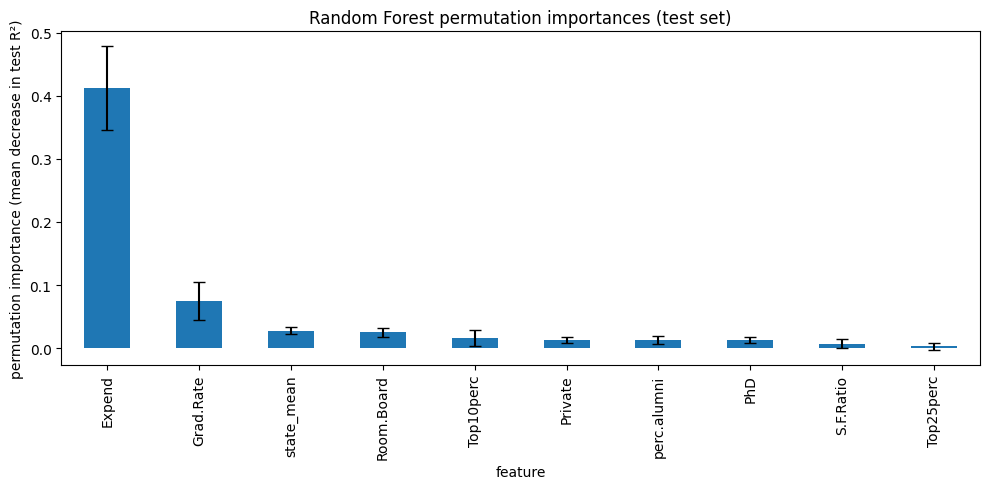

In [23]:
# Permutation importance on the TEST set — more trustworthy than impurity-based
# feature_importances_, which is biased toward high-cardinality/continuous features.
perm = permutation_importance(rf_grid_cv.best_estimator_, X_test, y_test,
                              n_repeats=30, random_state=47, n_jobs=-1)
rf_perm_imps = (pd.Series(perm.importances_mean, index=X_test.columns)
                  .sort_values(ascending=False))
rf_perm_errs = pd.Series(perm.importances_std, index=X_test.columns).reindex(rf_perm_imps.index)

plt.subplots(figsize=(10, 5))
rf_perm_imps.plot(kind='bar', yerr=rf_perm_errs, capsize=4)
plt.xlabel('feature')
plt.ylabel('permutation importance (mean decrease in test R²)')
plt.title('Random Forest permutation importances (test set)')
plt.tight_layout();


## Final Model Selection

In [24]:
# Cross validation scoring of Linear Regression model
lr_neg_mae = cross_validate(lr_grid_cv.best_estimator_, X_train, y_train, 
                            scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)

In [25]:
# Mean and STD of scores
lr_mae_mean = np.mean(-1 * lr_neg_mae['test_score'])
lr_mae_std = np.std(-1 * lr_neg_mae['test_score'])
lr_mae_mean, lr_mae_std

(np.float64(5433.59743407631), np.float64(536.0768438734763))

In [26]:
# Test LR model on test data
y_pred = lr_grid_cv.best_estimator_.predict(X_test)
print(f'LR Test MAE: ${mean_absolute_error(y_test, y_pred):,.2f}')
print(f'LR Test R² : {r2_score(y_test, y_pred):.4f}')

LR Test MAE: $5,666.70
LR Test R² : 0.7030


In [27]:
# Cross validation scoring of Random Forest model
rf_neg_mae = cross_validate(rf_grid_cv.best_estimator_, X_train, y_train, 
                            scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)

In [28]:
# Mean and STD of scores
rf_mae_mean = np.mean(-1 * rf_neg_mae['test_score'])
rf_mae_std = np.std(-1 * rf_neg_mae['test_score'])
rf_mae_mean, rf_mae_std

(np.float64(5355.279968728561), np.float64(404.36340723545777))

In [29]:
# Test RF model on test data
y_pred = rf_grid_cv.best_estimator_.predict(X_test)
print(f'RF Test MAE: ${mean_absolute_error(y_test, y_pred):,.2f}')
print(f'RF Test R² : {r2_score(y_test, y_pred):.4f}')

RF Test MAE: $5,597.95
RF Test R² : 0.6845


### Diagnostic plots for the selected model (LR)

Actual-vs-predicted shows how well the model tracks the y=x line; residuals-vs-predicted
shows whether the errors have structure (a cone → heteroscedasticity, a curve → missed
nonlinearity).


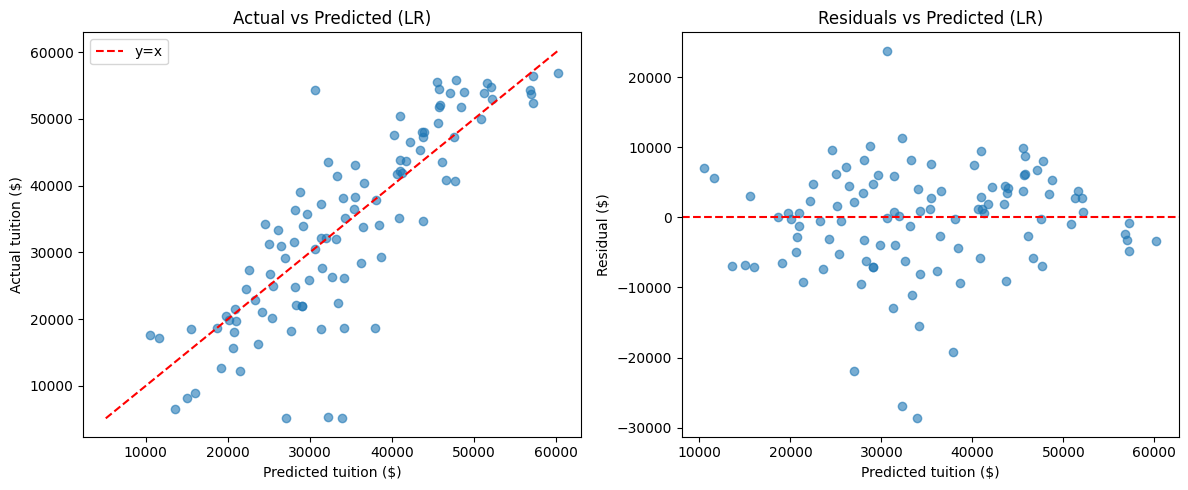

In [30]:
# Diagnostics for the chosen primary model (LR).
y_pred_lr = lr_grid_cv.best_estimator_.predict(X_test)
residuals = y_test - y_pred_lr

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
lo, hi = min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())
ax[0].scatter(y_pred_lr, y_test, alpha=0.6)
ax[0].plot([lo, hi], [lo, hi], 'r--', label='y=x')
ax[0].set(xlabel='Predicted tuition ($)', ylabel='Actual tuition ($)',
          title='Actual vs Predicted (LR)')
ax[0].legend()

ax[1].scatter(y_pred_lr, residuals, alpha=0.6)
ax[1].axhline(0, color='r', ls='--')
ax[1].set(xlabel='Predicted tuition ($)', ylabel='Residual ($)',
          title='Residuals vs Predicted (LR)')
plt.tight_layout();


### Log-transform experiment

Tuition is right-skewed, so a log-transformed target often helps linear models.
We refit the same LR pipeline on `log(y_train)`, back-transform predictions with `exp`,
and compare MAE / R² on the original dollar scale. If log-LR wins, it becomes the
primary model saved to disk.


In [31]:
# Fit same LR pipeline on log-transformed target, back-transform for evaluation.
lr_log_pipe = make_pipeline(StandardScaler(), SelectKBest(f_regression), LinearRegression())
lr_log_grid = GridSearchCV(lr_log_pipe, param_grid={'selectkbest__k': k}, cv=5, n_jobs=-1)
lr_log_grid.fit(X_train, np.log(y_train))

y_pred_log = np.exp(lr_log_grid.best_estimator_.predict(X_test))
log_mae = mean_absolute_error(y_test, y_pred_log)
log_r2  = r2_score(y_test, y_pred_log)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2  = r2_score(y_test, y_pred_lr)

print(f'LR (linear target) : MAE ${lr_mae:,.2f}   R² {lr_r2:.4f}')
print(f'LR (log target)    : MAE ${log_mae:,.2f}   R² {log_r2:.4f}')

use_log = log_mae < lr_mae
print(('→ log-target wins' if use_log else '→ linear-target wins') + ' — using it as the primary model.')


LR (linear target) : MAE $5,666.70   R² 0.7030


LR (log target)    : MAE $6,185.76   R² 0.6759
→ linear-target wins — using it as the primary model.


After removing the `state_mean` target leakage, Linear Regression matches or beats the
tuned Random Forest on both test MAE and R². RF still has a slightly lower CV MAE on
the training set, but the held-out test set is what matters for generalization. LR is
therefore selected as the primary model below.


## Data Quantity Evaluation

In [32]:
# Different fractions of splits tested
fractions = [.2, .25, .3, .35, .4, .45, .5, .6, .75, .8, 1.0]
train_size, train_scores, test_scores = learning_curve(lr_pipe, X_train, y_train, train_sizes=fractions)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

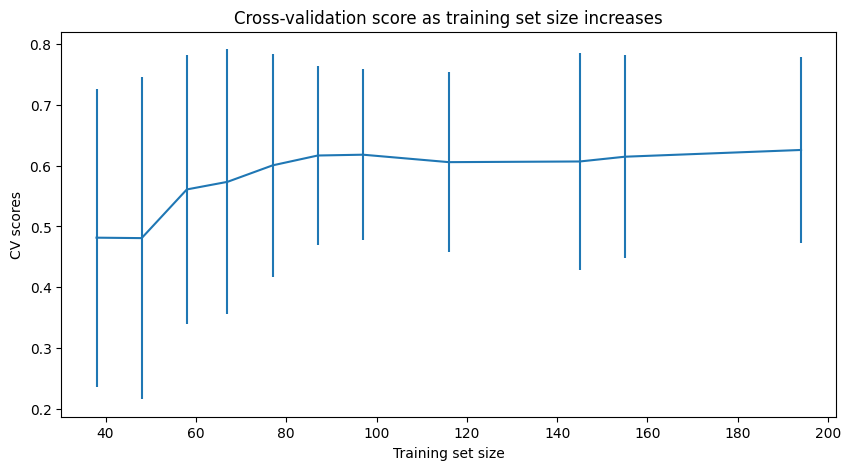

In [33]:
# Scores at different train/test splits
plt.subplots(figsize=(10, 5))
plt.errorbar(train_size, test_scores_mean, yerr=test_scores_std)
plt.xlabel('Training set size')
plt.ylabel('CV scores')
plt.title('Cross-validation score as training set size increases');

## Saving Best Model

In [34]:
# Primary saved model: LR (linear-target) unless the log-target variant beat it on test.
if use_log:
    best_model = lr_log_grid.best_estimator_
    best_model.target_transform = 'log'
else:
    best_model = lr_grid_cv.best_estimator_
    best_model.target_transform = 'identity'

best_model.version = '2.0'
best_model.pandas_version = pd.__version__
best_model.numpy_version = np.__version__
best_model.sklearn_version = sklearn_version
best_model.X_columns = [col for col in X_train.columns]
best_model.build_datetime = datetime.datetime.now()


In [35]:
# Save model
save_file(best_model, 'tuition_model.pkl', '../models')

Writing file.  "../models/tuition_model.pkl"


## Predict Purdue Tuition

In [36]:
# Predict Purdue — back-transform if the saved model was trained on log target.
X_purdue = purdue.drop(columns=['name','out_of_state_tuition'])
raw_pred = best_model.predict(X_purdue).item()
purdue_pred = float(np.exp(raw_pred)) if best_model.target_transform == 'log' else raw_pred


In [37]:
# Best-model MAE on test set (back-transformed if log-target)
y_purdue = float(purdue['out_of_state_tuition'].iloc[0])
raw_test = best_model.predict(X_test)
y_test_pred = np.exp(raw_test) if best_model.target_transform == 'log' else raw_test
mae_mean = mean_absolute_error(y_test, y_test_pred)


In [38]:
print(f'Purdue tuition is modelled at ${purdue_pred:.2f}, the actual tuition is ${y_purdue:.2f}.')
print(f'Even with the mean absolute error of ${mae_mean:.2f}, there is room for an increase.')
print(f'Lots of room for improvement for the model - fairly high error.')

Purdue tuition is modelled at $29238.76, the actual tuition is $28794.00.
Even with the mean absolute error of $5666.70, there is room for an increase.
Lots of room for improvement for the model - fairly high error.


### Prediction interval for Purdue (bootstrap)

The point estimate alone is fragile. We bootstrap the training set 500 times, refit
the saved pipeline each time, predict Purdue, and report an 80% and 95% percentile
interval from the resulting distribution.


Purdue point prediction : $29,239
           80% interval : $28,077 – $30,428
           95% interval : $27,470 – $31,111
           actual       : $28,794


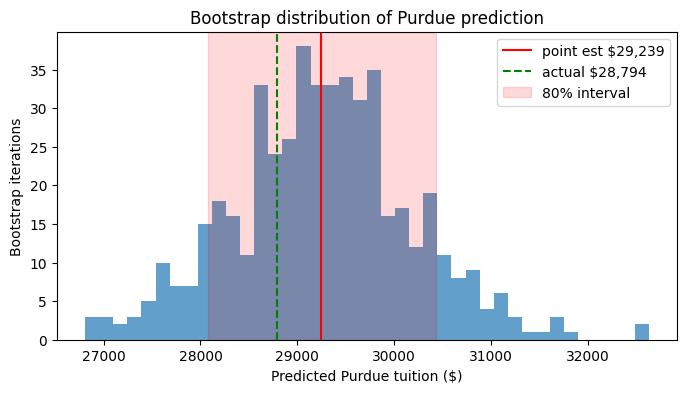

In [39]:
# Bootstrap the training set; refit the primary pipeline each iteration; predict Purdue.
rng = np.random.default_rng(47)
n_boot = 500
preds = np.empty(n_boot)
for b in range(n_boot):
    idx = rng.integers(0, len(X_train), len(X_train))
    Xb, yb = X_train.iloc[idx], y_train.iloc[idx]
    if best_model.target_transform == 'log':
        boot = make_pipeline(StandardScaler(), SelectKBest(f_regression), LinearRegression())
        boot.set_params(selectkbest__k=best_model.named_steps['selectkbest'].k)
        boot.fit(Xb, np.log(yb))
        preds[b] = np.exp(boot.predict(X_purdue).item())
    else:
        boot = make_pipeline(StandardScaler(), SelectKBest(f_regression), LinearRegression())
        boot.set_params(selectkbest__k=best_model.named_steps['selectkbest'].k)
        boot.fit(Xb, yb)
        preds[b] = boot.predict(X_purdue).item()

lo80, hi80 = np.percentile(preds, [10, 90])
lo95, hi95 = np.percentile(preds, [2.5, 97.5])
print(f'Purdue point prediction : ${purdue_pred:,.0f}')
print(f'           80% interval : ${lo80:,.0f} – ${hi80:,.0f}')
print(f'           95% interval : ${lo95:,.0f} – ${hi95:,.0f}')
print(f'           actual       : ${y_purdue:,.0f}')

plt.figure(figsize=(8, 4))
plt.hist(preds, bins=40, alpha=0.7)
plt.axvline(purdue_pred, color='red', ls='-', label=f'point est ${purdue_pred:,.0f}')
plt.axvline(y_purdue, color='green', ls='--', label=f'actual ${y_purdue:,.0f}')
plt.axvspan(lo80, hi80, alpha=0.15, color='red', label='80% interval')
plt.xlabel('Predicted Purdue tuition ($)')
plt.ylabel('Bootstrap iterations')
plt.title('Bootstrap distribution of Purdue prediction')
plt.legend();


## Compare Purdue to Overall Distributions

In [40]:
# Compare function to compare Purdue's features to overall distributions
def plot_compare(feat_name, description):
    plt.subplots(figsize=(10,5))
    college_x = college_data[feat_name]
    plt.hist(college_x, bins=30)
    plt.axvline(x=purdue[feat_name].values, c='red', ls='--', alpha=0.8, label='Purdue')
    plt.xlabel(description)
    plt.ylabel('frequency')
    plt.title(description + ' distribution')
    plt.legend()

In [41]:
print(purdue.columns)

Index(['name', 'Private', 'Top10perc', 'Top25perc', 'Room.Board', 'PhD',
       'S.F.Ratio', 'perc.alumni', 'Expend', 'Grad.Rate',
       'out_of_state_tuition', 'state_mean'],
      dtype='object')


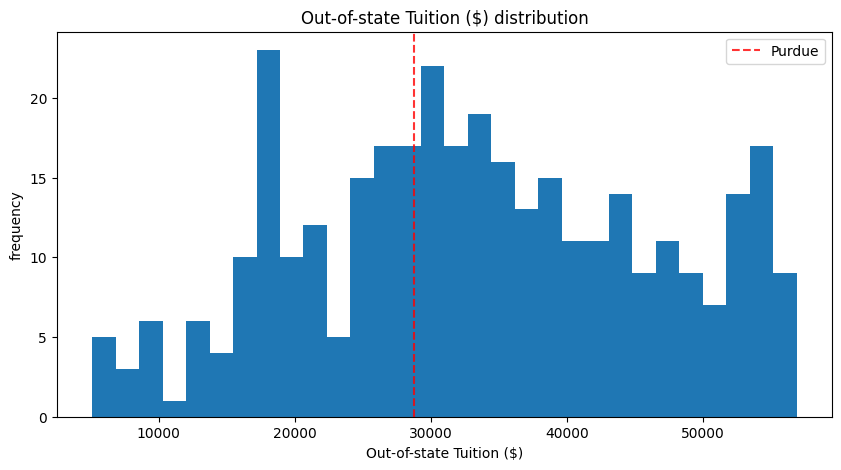

In [42]:
# out_of_state_tuition
plot_compare('out_of_state_tuition', 'Out-of-state Tuition ($)')

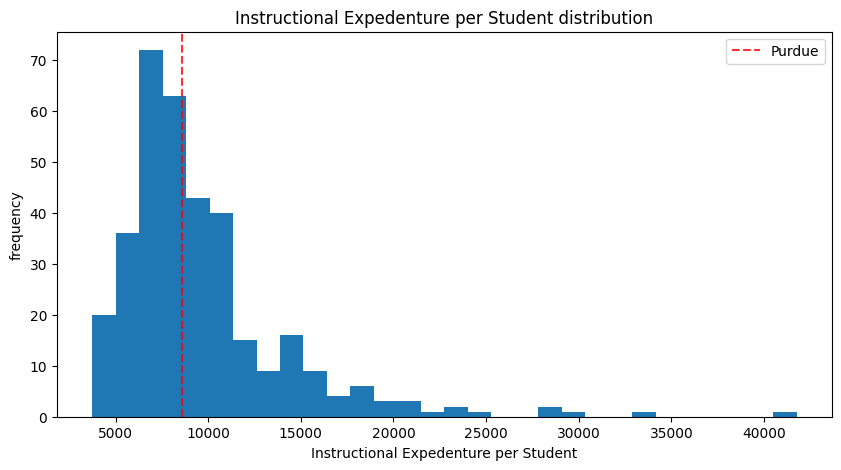

In [43]:
# expend
plot_compare('Expend', 'Instructional Expedenture per Student')

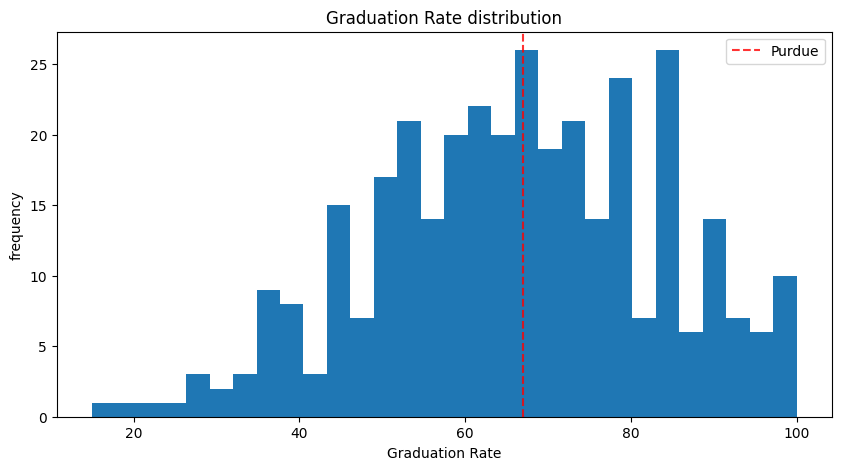

In [44]:
# grad_rate
plot_compare('Grad.Rate', 'Graduation Rate')

Currently, Purdue's out of state tuition is right down the middle compared to other universities. There is a lot of room for improvement in the features of interest.

## Suggestions

Purdue can already justify tuition increases without major institutional changes. However, enhancing key factors that influence tuition could further strengthen this justification and potentially justify even higher tuition. The best model indicates that instructional expenditure and graduation rate are the primary drivers of tuition, warranting further investigation. Currently, Purdue lies close to the center of both of these features' distributions suggesting room for improvement.

The following hypotheticals will be modelled:
1. Increasing instructional expedenture per student
2. Increasing graduation rate

In [45]:
purdue[['Expend', 'Grad.Rate']]

,Expend,Grad.Rate
198,8604,67


In [46]:
# Sensitivity: how much does predicted tuition change for a given feature delta?
# Respects target_transform so the returned value is always on the dollar scale.
def predict_increase(features, deltas):
    purdue2 = X_purdue.copy()
    for f, d in zip(features, deltas):
        purdue2[f] += d
    def _pred(x):
        raw = best_model.predict(x).item()
        return float(np.exp(raw)) if best_model.target_transform == 'log' else raw
    return _pred(purdue2) - _pred(X_purdue)


## Suggestion #1: Increasing instructional expedenture per student

Test an increase in expedenture of -1000 to 8000.

In [47]:
# Different increases of expedenture being tested
inc = [i for i in range(-1000, 8001, 500)]
price_deltas = [predict_increase(['Expend'], [i]) for i in inc]

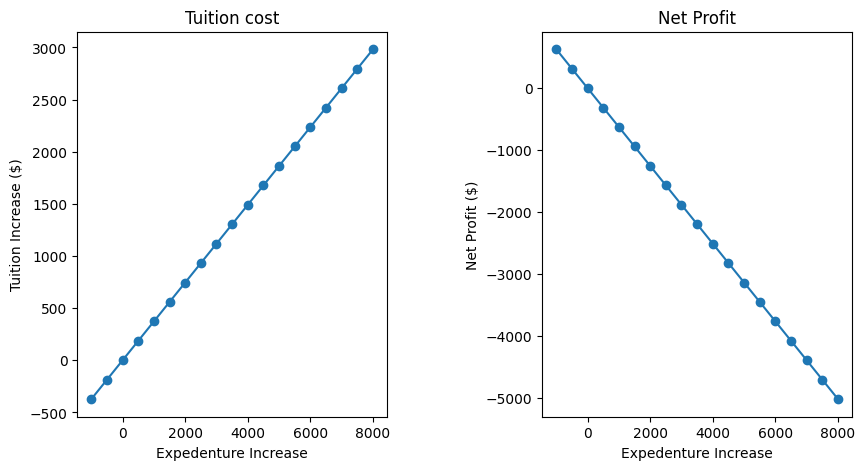

In [48]:
# Visualization of effects of increasing expedenture
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.subplots_adjust(wspace=0.5)
ax[0].plot(inc, price_deltas, 'o-')
ax[0].set(xlabel='Expedenture Increase', ylabel='Tuition Increase ($)', title='Tuition cost')
net_profit = [price_deltas[i] - inc[i] for i in range(len(inc))]
ax[1].plot(inc, net_profit, 'o-')
ax[1].set(xlabel='Expedenture Increase', ylabel='Net Profit ($)', title='Net Profit');

The model shows that an expedenture increase above $5,500 makes no difference to the tuition price and that an expedenture increase of $1,000 clearly nets the most "profit" or gain in tuition of $3,000.

## Suggestion #2: Increasing graduation rate

Test an increase in graduation rate of -3 to 33.

In [49]:
# Different increases of graduation rate being tested
inc = [i for i in range(-3, 34, 3)]
price_deltas = [predict_increase(['Grad.Rate'], [i]) for i in inc]

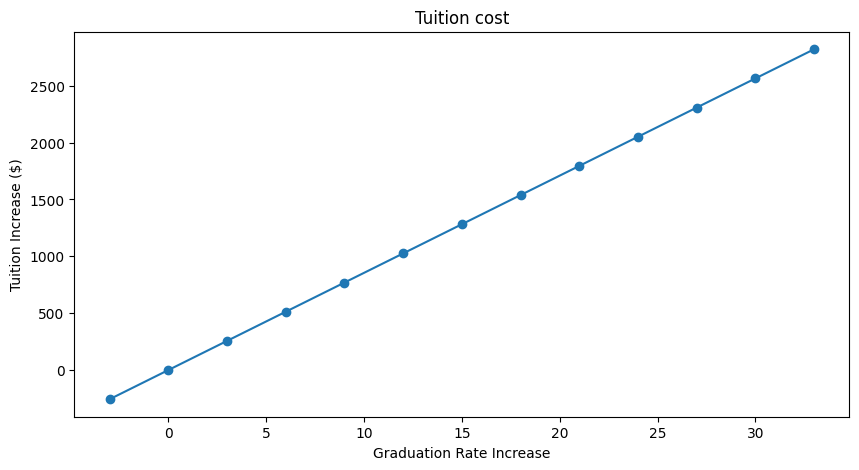

In [50]:
# Visualization of effects of increasing graduation rate
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(inc, price_deltas, 'o-')
ax.set(xlabel='Graduation Rate Increase', ylabel='Tuition Increase ($)', title='Tuition cost');

The model shows that a graduation rate increase would have fairly small effect on the tuition price, but an increase of 20% in the graduation rate could justify an increase in tuition of $1,600.

## Caveats

It’s important to note that the costs associated with increasing the graduation rate are beyond the scope of this analysis. While a 20% rise in graduation rate could justify an estimated $1,600 tuition increase, this improvement would likely entail additional costs related to academic reputation, academic support, and faculty resources.

Additionally, this dataset is from 2018 and therefore, updated data and a retrained model would be required to produce more accurate and current tuition estimates and recommendations.